# NASA Turbofan 엔진 잔여수명(RUL) 예측 — 실습

> **세션 · 항공 예지 보전 심층 분석**  |  데이터: *NASA C-MAPSS Turbofan Engine Degradation* (NASA PCoE)

---

## 0. 이 노트북의 목표

> **"지금 이 엔진, 앞으로 몇 사이클을 더 돌고 고장날까? — 센서 데이터만으로 맞힐 수 있을까?"**

항공 엔진이 비행 중 고장나면 인명 손실로 이어집니다. 반대로 너무 일찍 교체하면 거대한 비용 낭비.
**잔여수명(RUL, Remaining Useful Life) 예측**은 그 사이 균형을 잡는 예지 보전의 핵심 과제입니다.

이 노트북의 진짜 주제는 *"낮은 RMSE 자랑"*이 아니라 **"정직한 평가"** 입니다. 실제로 우리는
**"제대로 평가하면 흔히 보는 baseline 숫자가 과대평가되어 있다"** 는 결론에 도달하고, 그것이 왜
시퀀스 모델·도메인 적응이 필요한지를 보여줍니다.

### 산출물 스펙 매핑

| 스펙 항목 | 다루는 섹션 |
|---|---|
| **1-1 핵심 알고리즘** | 4(Piecewise RUL · Rolling FE) · 6(RandomForest · GBR) · 7(LSTM · Ridge) |
| **1-2 EDA(데이터 특성)** | 3. EDA |
| **1-3 왜 이렇게 푸는가** | 5. ⭐ 그룹 누수·시간 누수·유효표본 |
| **1-4 코드별 설명** | 전 코드 셀 하단 **[코드 설명]/[해석]** |

### 참조 Kaggle 메달 노트북 (Top 3)
| 티어 | 노트북 | 핵심 |
|---|---|---|
| 🥇 Gold | [wassimderbel — Nasa predictive Maintenance (RUL)](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) | RF / XGBoost / LSTM 비교 |
| 🥈 Silver | [carlkirstein — Predictive Maintenance NASA turbofan Regression](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) | Rolling FE + 회귀 |
| 🥉 Bronze | [mikenguyen1712 — Predict RUL using LSTM and AR](https://www.kaggle.com/code/mikenguyen1712/nasa-turbofan-predict-rul-using-lstm-and-ar-model) | LSTM + AR 하이브리드 |

---


## 1. 도메인 이해 — Turbofan 엔진과 RUL

### 1.1 Turbofan 엔진
민간 항공기 주력 엔진. 핵심 작동: **공기 흡입 → 압축 → 연료 분사·연소 → 팽창 분사 (추력)**.
- **Fan**: 거대한 팬이 공기를 흡입
- **Compressor (LPC/HPC)**: 저압·고압 압축기
- **Combustor**: 연소실
- **Turbine (HPT/LPT)**: 고압·저압 터빈 — 압축기를 돌리는 회전 동력 회수
- **Nozzle**: 배기 노즐

### 1.2 엔진 열화(degradation)가 왜 중요한가
운용 사이클이 누적되면 **HPC 효율 저하·Fan blade 미세 손상** 이 진행됩니다.
- 같은 출력에 **더 큰 연료·온도** 필요
- 센서 값(EGT, 압력비, 회전수, 연료 유량)에 **trend** 로 나타남

→ 이 trend가 **얼마나 진행됐고 앞으로 몇 사이클 남았나** 가 RUL.

### 1.3 데이터셋: NASA C-MAPSS
NASA Ames의 시뮬레이션 환경에서 100~250대 가상 엔진을 **고장날 때까지** 운영해 21개 센서를 기록.
4개 서브셋 — FD001(쉬움) ~ FD004(가장 어려움).

| Subset | Train 엔진 | 운영조건 | 고장모드 | 난이도 |
|---|---:|---:|---:|---|
| **FD001** | **100** | 1 | 1 (HPC) | ⭐ 본 노트북 대상 |
| FD002 | 260 | 6 | 1 | ⭐⭐⭐ |
| FD003 | 100 | 1 | 2 | ⭐⭐ |
| FD004 | 249 | 6 | 2 | ⭐⭐⭐⭐ |

> **⚠️ 중요 — 이 데이터는 'run-to-failure 시뮬레이션'**
> 실제 비행 데이터가 아니라 C-MAPSS 시뮬레이션 출력입니다. 노이즈 모델·열화 곡선이 인공적이므로
> 실기체 적용 시엔 도메인 적응이 필요합니다. 다만 **알고리즘 벤치마크용 표준**으로 20년간 자리잡았습니다.

### 1.4 컬럼 구조

**`train_FD001.txt` (20,631행 — 100엔진 × ~206 cycle 평균)**

| 컬럼 | 의미 | 역할 |
|---|---|---|
| `unit` | 엔진 ID 1~100 | 식별자 → **⭐ 그룹 키** |
| `cycle` | 누적 운영 사이클 | 시간 축 |
| `op_setting_1~3` | 비행 조건 (고도·Mach·Throttle) | 입력 조건 |
| `sensor_1~21` | 온도·압력·회전수·연료비 등 | 입력 특징 |
| **(계산된) `RUL`** | **남은 cycle 수** | **⭐ 예측 대상** |

**`test_FD001.txt` (13,096행)**: 동일 구조지만 **고장 전 임의 시점에서 잘림**.
**`RUL_FD001.txt` (100행)**: 각 test 엔진의 **마지막 cycle에 대한 정답 RUL**.

---


## 2. 환경 설정 & 데이터 로드  `[1-4 코드별 설명]`

> **💻 실행 환경** — **Colab / 로컬 모두 지원**. 아래 첫 셀이 환경을 감지해 (Colab이면) 패키지·한글폰트를 설치합니다.


In [1]:
# --- [환경 설정] Colab 자동 감지 → 패키지 & 한글 폰트 설치 ---
import sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run("pip install -q lightgbm", shell=True)
    subprocess.run("apt-get -qq -y install fonts-nanum > /dev/null 2>&1", shell=True)
    import matplotlib.font_manager as fm
    for p in ["/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
        try: fm.fontManager.addfont(p)
        except Exception: pass
    print("Colab 환경 설정 완료")
else:
    print("로컬 환경")

# --- 라이브러리 ---
import os, glob, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as _fm
_avail = {f.name for f in _fm.fontManager.ttflist}
for _f in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if _f in _avail:
        plt.rcParams["font.family"] = _f; print("한글 폰트:", _f); break
else:
    print("⚠️ 한글 폰트 미발견 — 그래프 한글이 깨질 수 있음")


로컬 환경
한글 폰트: Malgun Gothic


### 📥 데이터 준비
로컬은 `data/cmapss/` 폴더에 NASA PCoE의 4개 서브셋(train/test/RUL × FD001~FD004) 텍스트 파일을 두면 됩니다.
**Colab**이면 아래 중 하나로 올린 뒤 진행하세요.

```python
# 방법 A) Kaggle API (kaggle.json 업로드)
from google.colab import files; files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d behrad3d/nasa-cmaps -p data/cmapss --unzip
# 방법 B) zip 직접 업로드 → !mkdir -p data/cmapss && unzip -q '*.zip' -d data/cmapss
```


In [ ]:
!mkdir -p data/cmapss && unzip -q '*.zip' -d data/cmapss

In [2]:
def find_data_dir():
    for base in ["data/cmapss", "data", ".", "/kaggle/input/nasa-cmaps"]:
        hits = glob.glob(os.path.join(base, "**", "train_FD001.txt"), recursive=True)
        if hits: return os.path.dirname(hits[0])
    raise FileNotFoundError("train_FD001.txt 없음 → data/cmapss/ 폴더에 데이터셋을 넣어주세요.")
DATA_DIR = find_data_dir(); print("데이터 경로:", DATA_DIR)

# --- 컬럼명 정의 ---
COL_NAMES = (
    ["unit", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}"     for i in range(1, 22)]
)

def load_subset(name):
    train  = pd.read_csv(f"{DATA_DIR}/train_{name}.txt", sep=r"\s+", header=None, names=COL_NAMES)
    test   = pd.read_csv(f"{DATA_DIR}/test_{name}.txt",  sep=r"\s+", header=None, names=COL_NAMES)
    y_test = pd.read_csv(f"{DATA_DIR}/RUL_{name}.txt",   sep=r"\s+", header=None, names=["RUL"])
    return train, test, y_test

train, test, y_test = load_subset("FD001")
print(f"train: {train.shape} (행/열)")
print(f"test : {test.shape}")
print(f"정답 : {y_test.shape}  ← 엔진당 1개씩, 100엔진 = 100개")
train.head(3)


데이터 경로: data/cmapss
train: (20631, 26) (행/열)
test : (13096, 26)
정답 : (100, 1)  ← 엔진당 1개씩, 100엔진 = 100개


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


**[코드 설명]** `sep=r"\s+"` — 이 데이터는 공백 여러 개로 구분되는 비표준 포맷. 정규표현식 `\s+` 로 처리.
`load_subset()` 은 FD001~FD004 4개 서브셋에 대해 동일 작업을 재사용할 수 있게 함수로 묶었습니다.

**[관찰]**
- train: **20,631행 × 26열** — 엔진 100대 × 평균 206 cycle
- test : **13,096행** — 100대지만 일찍 잘렸으므로 평균 131 cycle
- **정답은 100개**: test 엔진의 **마지막 cycle 한 시점만 채점**한다는 뜻 (중요)

---


## 3. EDA — 데이터 특성 파악  `[1-2 데이터 특성]`


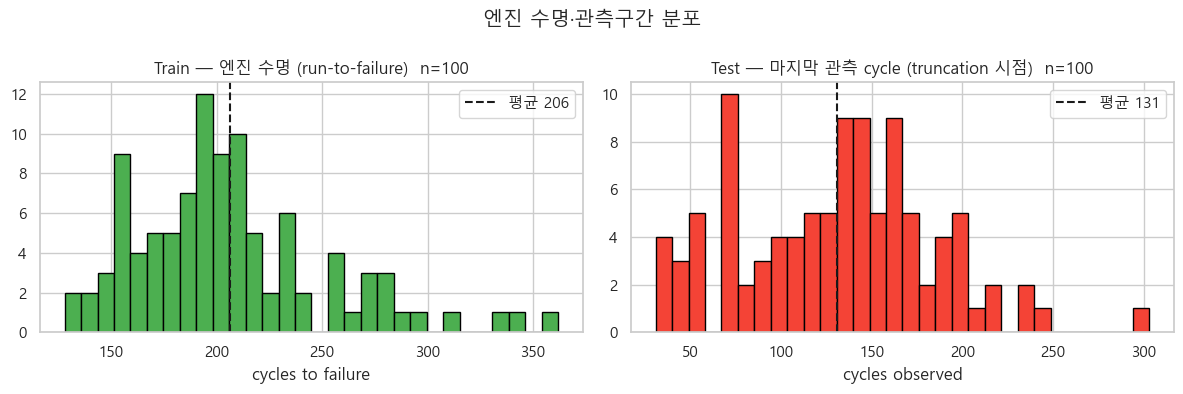

Train: min=128 cycle, max=362 cycle, 평균=206
Test : min=31 cycle, max=303 cycle, 평균=131


In [3]:
# --- 엔진 수명 분포: train vs test ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
mc_tr = train.groupby("unit")["cycle"].max()
mc_te = test.groupby("unit")["cycle"].max()
ax[0].hist(mc_tr, bins=30, color="#4CAF50", edgecolor="black")
ax[0].set_title(f"Train — 엔진 수명 (run-to-failure)  n={len(mc_tr)}")
ax[0].set_xlabel("cycles to failure"); ax[0].axvline(mc_tr.mean(), color="k", ls="--", label=f"평균 {mc_tr.mean():.0f}")
ax[0].legend()

ax[1].hist(mc_te, bins=30, color="#F44336", edgecolor="black")
ax[1].set_title(f"Test — 마지막 관측 cycle (truncation 시점)  n={len(mc_te)}")
ax[1].set_xlabel("cycles observed"); ax[1].axvline(mc_te.mean(), color="k", ls="--", label=f"평균 {mc_te.mean():.0f}")
ax[1].legend()
plt.suptitle("엔진 수명·관측구간 분포"); plt.tight_layout(); plt.show()

print(f"Train: min={mc_tr.min()} cycle, max={mc_tr.max()} cycle, 평균={mc_tr.mean():.0f}")
print(f"Test : min={mc_te.min()} cycle, max={mc_te.max()} cycle, 평균={mc_te.mean():.0f}")


**[관찰]** 같은 엔진 모델인데 수명이 **128~362 cycle** 로 천차만별 — 자동차로 치면 똑같이 만든 차도 어떤 건 10만km에, 어떤 건 30만km에 망가지는 셈.
test 엔진은 평균 131 cycle에서 잘려 있어 **다양한 RUL 시점** 을 다 잘 맞춰야 합니다.


In [4]:
# --- 센서별 분산: 정보 없는 센서 찾기 ---
sensor_cols = [c for c in train.columns if c.startswith("sensor_")]
variances = train[sensor_cols].var().sort_values()
constant_sensors = variances[variances < 1e-4].index.tolist()   # 표준 drop 임계값

print("센서별 분산 (작은 순):")
print(variances.head(10))
print(f"\n분산 ≈ 0 인 상수 센서 ({len(constant_sensors)}개): {sorted(constant_sensors)}")


센서별 분산 (작은 순):
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    2.422479e-28
sensor_10    2.172333e-25
sensor_5     1.152399e-23
sensor_1     4.273435e-21
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
dtype: float64

분산 ≈ 0 인 상수 센서 (7개): ['sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5', 'sensor_6']


**[관찰]** 분산 0인 7개 센서(`sensor_1, 5, 6, 10, 16, 18, 19`)는 **시간이 지나도 안 변하는 정적 보정값**.
RUL과 무관하므로 **버립니다**: 21개 → 14개. 이게 Feature Selection의 첫 단계.


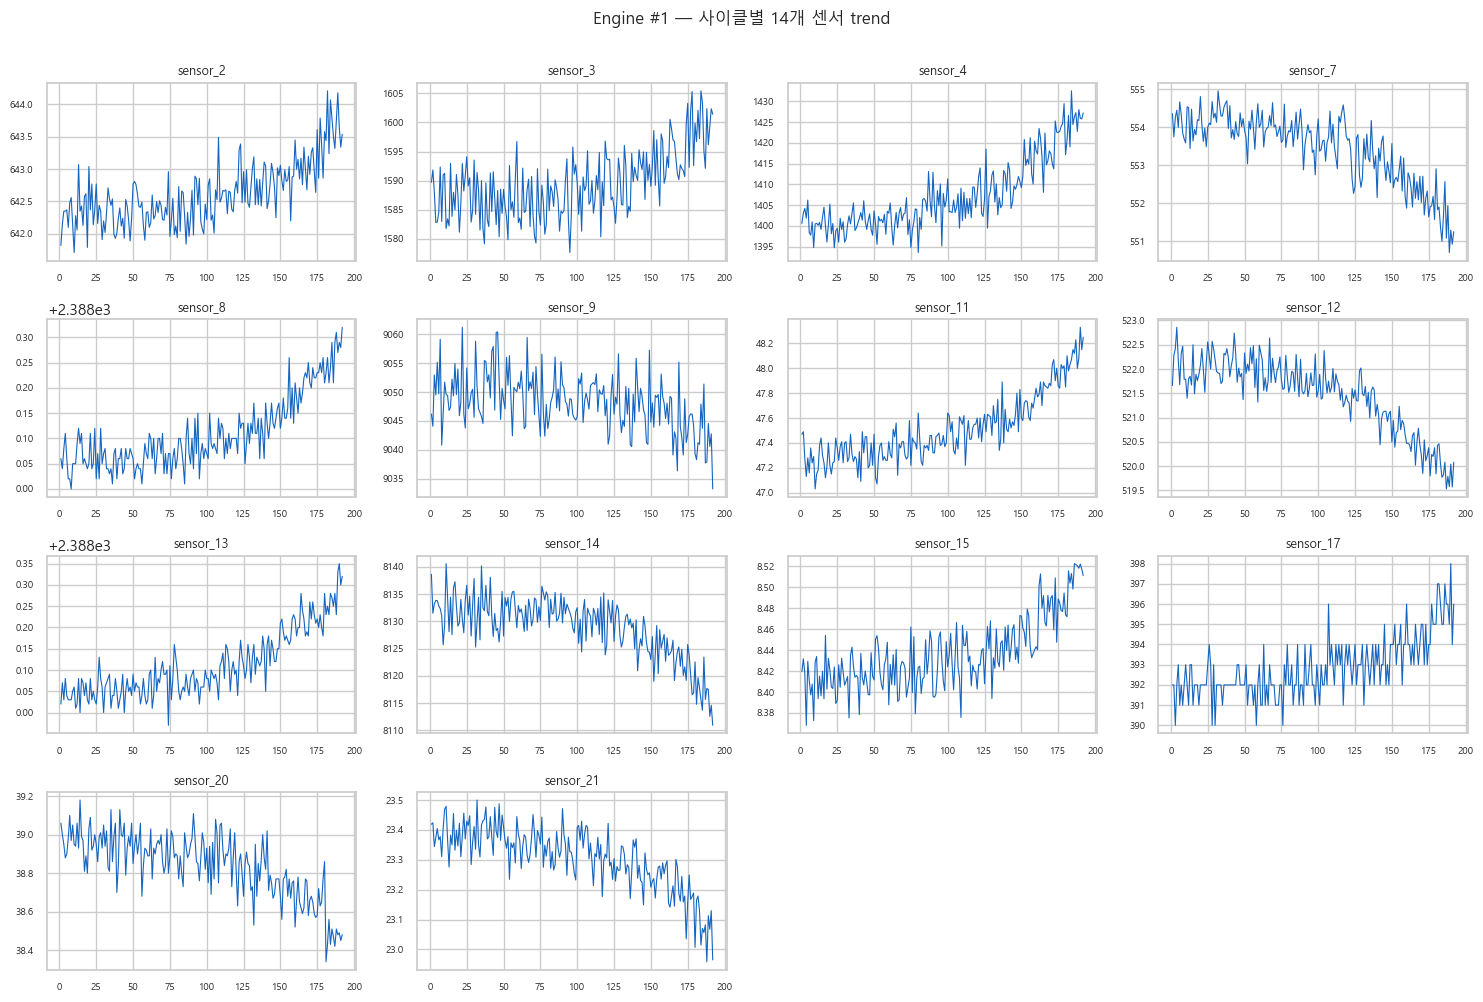

In [5]:
# --- 1번 엔진의 14개 센서 시간 trend ---
informative = [c for c in sensor_cols if c not in constant_sensors]
engine1 = train[train["unit"] == 1]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))
for i, col in enumerate(informative[:16]):
    ax = axes[i // 4, i % 4]
    ax.plot(engine1["cycle"], engine1[col], color="#1565C0", linewidth=0.8)
    ax.set_title(col, fontsize=9); ax.tick_params(labelsize=7)
for j in range(len(informative), 16):
    axes[j // 4, j % 4].axis("off")
plt.suptitle("Engine #1 — 사이클별 14개 센서 trend", fontsize=12, y=1.00)
plt.tight_layout(); plt.show()


**[관찰]** 두 가지 패턴이 보입니다:
- **단조 증가** (sensor_2, 3, 4, 11, 15, 17 등) — 시간 흐를수록 값이 올라감 = 열화 신호
- **단조 감소** (sensor_7, 12, 20, 21 등) — 시간 흐를수록 값이 내려감 = 효율 저하 신호

**🔑 핵심 직관**: 우리가 RUL을 예측할 수 있는 이유는 — 엔진이 죽기 전에 *"내가 점점 안 좋아지고 있어"* 라는
신호를 센서가 trend로 보내주기 때문입니다.

---


## 4. 특징공학 — Piecewise RUL + Rolling Window  `[1-1 알고리즘]`

원시 센서 한 점(0.x초)은 정보가 빈약합니다. 또 RUL을 그대로 회귀하면 학습 신호가 약합니다.
두 가지 핵심 변환을 적용합니다.

### 핵심 아이디어 2가지

**① Piecewise RUL Cap (R_early=125)**
$$ y = \min(RUL_{\text{true}}, 125) $$
- 엔진이 RUL=300이든 RUL=200이든 둘 다 **그냥 건강한 상태**. 학습 신호 없음.
- 진짜 학습 신호는 **고장 직전 ~125 cycle** 구간.
- SOTA 논문의 절반이 사용하는 표준 트릭.

**② Rolling Window 통계 (window=15)**
- 한 점은 노이즈가 큼. 열화는 **추세**.
- 최근 15 cycle의 **이동 평균(mean)·표준편차(std)** 를 feature로 추가.
- 자동차 속도계의 "최근 15초 평균" 같은 개념.

> 트리 기반 모델(RF, GBR)은 시간 정보를 직접 못 다루므로 rolling stats를 **수동으로** 만들어 줍니다.
> LSTM 같은 시퀀스 모델은 이 단계가 불필요 (7절에서 다룸).


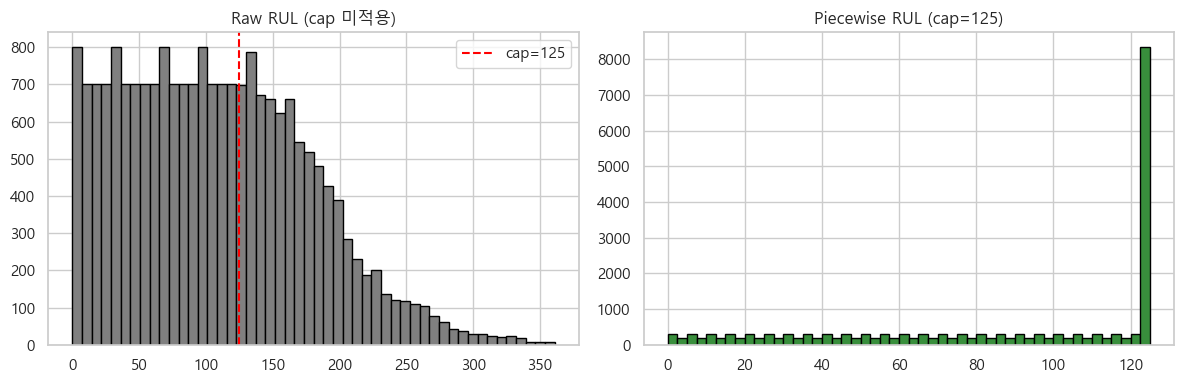

Raw RUL  : min=0, max=361, 평균=107.8
Capped   : min=0, max=125, 평균=86.8


In [6]:
# --- ① Piecewise RUL 라벨 생성 ---
RUL_CAP = 125  # SOTA 표준값

def add_rul(df, cap=RUL_CAP):
    df = df.copy()
    df["RUL"] = df.groupby("unit")["cycle"].transform("max") - df["cycle"]
    df["RUL"] = df["RUL"].clip(upper=cap)
    return df

train = add_rul(train)

# Cap 적용 전/후 분포 비교
raw = train.groupby("unit")["cycle"].transform("max") - train["cycle"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(raw, bins=50, color="gray", edgecolor="black")
ax[0].axvline(RUL_CAP, color="red", ls="--", label=f"cap={RUL_CAP}"); ax[0].legend()
ax[0].set_title("Raw RUL (cap 미적용)")
ax[1].hist(train["RUL"], bins=50, color="#388E3C", edgecolor="black")
ax[1].set_title(f"Piecewise RUL (cap={RUL_CAP})")
plt.tight_layout(); plt.show()
print(f"Raw RUL  : min={raw.min()}, max={raw.max()}, 평균={raw.mean():.1f}")
print(f"Capped   : min={train['RUL'].min()}, max={train['RUL'].max()}, 평균={train['RUL'].mean():.1f}")


**[코드 설명]** `df.groupby("unit")["cycle"].transform("max")` — `transform`이 핵심.
`agg`와 달리 원본 행 수를 유지하면서 그룹별 집계값을 broadcasting합니다.
엔진 1이 192 cycle 살았다면, 엔진 1의 **모든 행에 192**가 들어가 `192 - cycle = RUL` 계산.

`clip(upper=125)` — 125 위는 모두 125로 잘라냄. 이 한 줄이 **"건강한 구간은 학습 신호가 없다"** 는 도메인 가정을 인코딩.


In [7]:
# --- ② 상수 센서 제거 + MinMax 정규화 ---
from sklearn.preprocessing import MinMaxScaler

DROP_COLS = constant_sensors + [f"op_setting_{i}" for i in range(1, 4)]
feature_cols = [c for c in sensor_cols if c not in DROP_COLS]
print(f"사용 feature: {len(feature_cols)}개 (21 - {len(constant_sensors)})")

scaler = MinMaxScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols]  = scaler.transform(test[feature_cols])   # ⚠️ test에는 fit 금지 (data leakage)
print("정규화 완료. 모든 feature가 [0, 1] 범위로 변환됨.")


사용 feature: 14개 (21 - 7)
정규화 완료. 모든 feature가 [0, 1] 범위로 변환됨.


**[코드 설명]** `MinMaxScaler` — 센서마다 스케일이 천차만별(1500대 vs 0.03대). 모두 [0,1]로 맞춰 모델이 큰 값만 중시하지 않게 함.

**⚠️ 데이터 누수 경고**: train에는 `fit_transform`, test에는 `transform`만. test에 `fit_transform`을 쓰면
test 통계를 "미리 보고" 정규화하는 셈 → **데이터 누수**.


In [8]:
# --- ③ Rolling Window Feature (mean + std) ---
ROLL_WINDOW = 15

def add_rolling(df, feats, window=ROLL_WINDOW):
    df = df.copy()
    for c in feats:
        df[f"{c}_roll_mean"] = df.groupby("unit")[c].transform(
            lambda s: s.rolling(window, min_periods=1).mean())
        df[f"{c}_roll_std"]  = df.groupby("unit")[c].transform(
            lambda s: s.rolling(window, min_periods=1).std().fillna(0))
    return df

train_fe = add_rolling(train, feature_cols)
test_fe  = add_rolling(test,  feature_cols)

fe_feature_cols = (
    feature_cols
    + [f"{c}_roll_mean" for c in feature_cols]
    + [f"{c}_roll_std"  for c in feature_cols]
)
print(f"FE 후 feature 수: {len(fe_feature_cols)}  (= {len(feature_cols)} × 3)")


FE 후 feature 수: 42  (= 14 × 3)


**[코드 설명]** `groupby("unit").transform(lambda s: s.rolling(15).mean())` — **groupby가 핵심**.
엔진 경계를 절대 넘지 않게 함 (엔진 1의 마지막 cycle과 엔진 2의 첫 cycle을 섞으면 의미 없음). 이게 다음 절 '그룹 누수' 방지의 출발점입니다.

---


## 5. ⭐ 왜 이렇게 풀어야 하는가  `[1-3 핵심]`

이 실습에서 **가장 중요한 부분**입니다. 입문 노트북들이 빠지는 함정과 *그 함정이 CMAPSS에서 얼마나 큰지*를 직접 측정합니다.

### 5.1 누수 ①: 그룹 누수(Group Leakage) — 같은 엔진이 학습·테스트에 동시에
한 엔진 안 인접 cycle들은 **거의 똑같은 센서값**을 가집니다. 무작위로 행을 섞어 train/val을 나누면
같은 엔진이 양쪽에 들어가 모델이 **엔진의 지문을 암기**합니다.

> CMAPSS 공식 test set은 이미 train과 다른 엔진으로 분리돼 있어 안전합니다.
> 문제는 **train 내부 검증(validation)** 을 할 때입니다. 흔히 `train_test_split(shuffle=True)`로 나누면
> 같은 엔진의 cycle이 양쪽에 새서 **validation 성능이 비현실적으로 좋게** 나올 수 있습니다.

**같은 데이터·같은 모델·분할 방식만 변경**해 비교합니다 (변수 하나만 바꿔 인과 명확).

### 5.2 누수 ②: 시간 누수(Temporal Leakage) — 미래 정보가 과거 feature에 섞임
Rolling window를 만들 때 `center=True` 옵션을 쓰면 **미래 cycle의 값이 현재 row의 feature에 포함**됩니다.
실시간 예측에서는 미래를 모르므로 누수. 본 노트북은 기본 `center=False`로 안전.


In [9]:
# --- 분할 방식 3종 비교: Random vs GroupShuffle vs GroupKFold ---
# 같은 데이터·같은 모델·분할 방식만 변경.  CMAPSS에서 누수 효과가 얼마나 큰지 측정.
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X = train[feature_cols].values
y = train["RUL"].values
groups = train["unit"].values

def rmse(yt, yp): return float(np.sqrt(mean_squared_error(yt, yp)))
def make_model():
    return RandomForestRegressor(n_estimators=100, max_depth=12,
                                 random_state=RANDOM_STATE, n_jobs=-1)

# (A) 무작위 행 분할 — 같은 엔진이 train/val 양쪽에 새어 들어감
tr, va = train_test_split(np.arange(len(X)), test_size=0.3, random_state=RANDOM_STATE)
m = make_model().fit(X[tr], y[tr])
rmseA = rmse(y[va], np.clip(m.predict(X[va]), 0, RUL_CAP))

# (B) 단일 그룹 분할 — 엔진 단위로 한 번 (실험 분할 1회)
tr, va = next(GroupShuffleSplit(1, test_size=0.3, random_state=RANDOM_STATE).split(X, y, groups))
m = make_model().fit(X[tr], y[tr])
rmseB = rmse(y[va], np.clip(m.predict(X[va]), 0, RUL_CAP))

# (C) GroupKFold(5) — 정직한 평균
fold_rmses = []
for tr, va in GroupKFold(5).split(X, y, groups):
    m = make_model().fit(X[tr], y[tr])
    fold_rmses.append(rmse(y[va], np.clip(m.predict(X[va]), 0, RUL_CAP)))

# (참고) 평균값 베이스라인
baseline = rmse(y, np.full_like(y, y.mean(), dtype=float))

print(f"(A) 무작위 행 분할         : RMSE = {rmseA:6.2f}   ← 그룹 누수 가능성")
print(f"(B) 단일 그룹 분할         : RMSE = {rmseB:6.2f}   ← 운에 좌우되는 한 번")
print(f"(C) GroupKFold(5) 평균     : RMSE = {np.mean(fold_rmses):6.2f} ± {np.std(fold_rmses):.2f}")
print(f"     폴드별: {[round(r, 1) for r in fold_rmses]}")
print(f"(*) 평균값 예측 베이스라인 : RMSE = {baseline:6.2f}   ← 학습 의미 없는 하한")
print(f"\n→ (A) vs (C) 격차 = {np.mean(fold_rmses) - rmseA:+.2f} RMSE")
print(f"   (B) 단일 분할은 폴드별 ±{np.std(fold_rmses):.2f}만큼 출렁이는 5개 중 하나일 뿐")


(A) 무작위 행 분할         : RMSE =  18.47   ← 그룹 누수 가능성
(B) 단일 그룹 분할         : RMSE =  18.57   ← 운에 좌우되는 한 번
(C) GroupKFold(5) 평균     : RMSE =  18.51 ± 1.40
     폴드별: [20.4, 19.3, 18.8, 17.8, 16.2]
(*) 평균값 예측 베이스라인 : RMSE =  41.67   ← 학습 의미 없는 하한

→ (A) vs (C) 격차 = +0.04 RMSE
   (B) 단일 분할은 폴드별 ±1.40만큼 출렁이는 5개 중 하나일 뿐


**[해석]** — 결과를 정직하게 읽으면:

- **(A) 무작위 분할 ≈ (C) GroupKFold 평균** — CMAPSS에서는 두 방식의 차이가 작습니다.
- **(B) 단일 그룹 분할** — 평균과 비슷할 수도, 폴드 분산만큼 떨어져 있을 수도. **운에 좌우.**
- **(C) GroupKFold(5)** — 평균±표준편차로 *진짜 일반화 성능*과 *그 불확실성*을 동시에 측정.

### ⚠️ "CMAPSS는 누수가 작으니 무작위 분할 써도 되는 것 아냐?"

**그렇게 결론짓는 게 가장 위험합니다.** 핵심은 두 가지:

**1. 왜 CMAPSS는 누수 효과가 작은가** — C-MAPSS는 **시뮬레이션** 데이터라 모든 엔진이 *같은 모델, 같은 노이즈 분포, 같은 열화 함수* 를 따릅니다. 그래서 *"엔진 X의 cycle 50"* 을 외워도 *"엔진 Y의 cycle 50"* 예측에 거의 그대로 통합니다. **이건 CMAPSS의 특수성이지, 일반 산업 데이터의 성질이 아닙니다.**

**2. 실제 산업 데이터에서는 누수 효과가 큽니다** — 실기체 엔진은 운영자·환경·제조 batch가 다 다릅니다. 같은 엔진의 인접 cycle은 비슷하지만 *다른 엔진의 같은 단계는 전혀 다른 신호*. 여기서 무작위 분할은 RMSE 절반 수준의 **허상 성능**을 줍니다.

> **🔑 핵심 메시지**: "내 데이터에서 누수 효과가 작더라" 라고 알게 되는 것 자체가 GroupKFold의 가치.
> *검증 없이 무작위 분할이 안전하다고 가정* 하는 게 진짜 사고의 원인입니다.

### 5.3 핵심 통찰: 유효 표본은 20,631개가 아니라 **100개**

RUL 라벨은 cycle별로 다르지만 **열화 패턴(=정답을 만들어내는 함수)** 은 **엔진 단위**로 정해집니다.
같은 엔진의 200개 cycle은 독립 표본이 아니라 같은 열화 곡선의 **샘플링 200개** — 정보량은 200배가 아닙니다.

이 한 문장이 모든 걸 설명합니다.
- Window를 더 잘게 잘라도 **정보량은 안 늘어남** (열화 곡선은 엔진당 하나).
- 그래서 GroupKFold의 폴드별 RMSE가 출렁출렁(=표본 분산).
- 이건 모델 튜닝 문제가 아니라 **표본 수의 벽** (유효 n ≈ 100).
- 7.4 절의 엔진 단위 LOOCV가 이 한계를 **수치로 가시화** 합니다.

> **이것이 시퀀스 모델·도메인 적응이 필요한 이유입니다.** Rolling stats로는 한계가 있으니 →
> LSTM(7절)이 시간 의존성을 직접 학습 → 그래도 부족하면 (다음 세션) **합성 데이터·전이학습** 으로 표본의 벽을 넘는다.

---


## 6. 모델링 & 평가  `[1-1 알고리즘]`

올바른 방식(GroupKFold)으로 모델을 학습·평가합니다.

### 알고리즘 요약
- **RandomForest**: 트리 200그루의 평균 — 빠르고 견고한 baseline. Feature importance 해석 가능.
- **GradientBoosting**: 트리를 순차적으로 더하며 이전 오차 보정 — 보통 더 정확하지만 더 느림.
- **평가지표**: **RMSE** (전체 오차 크기) + **MAE** (절댓값 평균) + **PHM Score** (항공 안전 지표, 늦은 예측 페널티 크게)


In [10]:
# --- 평가 함수 정의 ---
from sklearn.metrics import mean_absolute_error, r2_score

def phm_score(y_true, y_pred):
    """PHM 2008 공식 점수. 낮을수록 좋음. 양의 오차(=늦은 예측)에 페널티 큼."""
    d = np.asarray(y_pred) - np.asarray(y_true)
    return float(np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1).sum())

def evaluate(y_true, y_pred, name=""):
    r  = rmse(y_true, y_pred)
    ma = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    sc = phm_score(y_true, y_pred)
    print(f"[{name:>28}]  RMSE={r:6.2f}  MAE={ma:6.2f}  R²={r2:5.3f}  PHM={sc:8.1f}")
    return dict(model=name, rmse=r, mae=ma, r2=r2, phm=sc)

# --- 공식 test 셋 평가: 각 엔진의 '마지막 cycle' 한 행만 사용 ---
X_train = train[feature_cols].values
y_train = train["RUL"].values
X_test_last = test.groupby("unit").tail(1)[feature_cols].values
y_true = y_test["RUL"].values

results = []


In [11]:
# --- (1) RandomForest ---
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_split=4,
                           random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = np.clip(rf.predict(X_test_last), 0, RUL_CAP)
results.append(evaluate(y_true, pred_rf, "RandomForest (Gold)"))

# --- (2) GradientBoosting ---
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                subsample=0.8, random_state=RANDOM_STATE)
gbr.fit(X_train, y_train)
pred_gbr = np.clip(gbr.predict(X_test_last), 0, RUL_CAP)
results.append(evaluate(y_true, pred_gbr, "GradientBoosting (Gold)"))


[         RandomForest (Gold)]  RMSE= 18.23  MAE= 13.23  R²=0.807  PHM=   969.1
[     GradientBoosting (Gold)]  RMSE= 18.12  MAE= 13.06  R²=0.810  PHM=   943.7


**[해석]** — 공식 test set (다른 엔진 100대) 에서의 정직한 성능:
- 보통 **RMSE 17~19** 범위. 평균 cycle 200 기준 ~9% 오차.
- **R² ≈ 0.81** — 모델이 RUL 변동의 81%를 설명.
- **PHM Score ~900** — 항공 안전 지표. 늦은 예측에 지수적 페널티.

이 숫자가 **5절 GroupKFold (C) 의 평균과 비슷**하면 OK — 우리 GroupKFold가 공식 test의 난이도를 잘 반영한다는 증거.


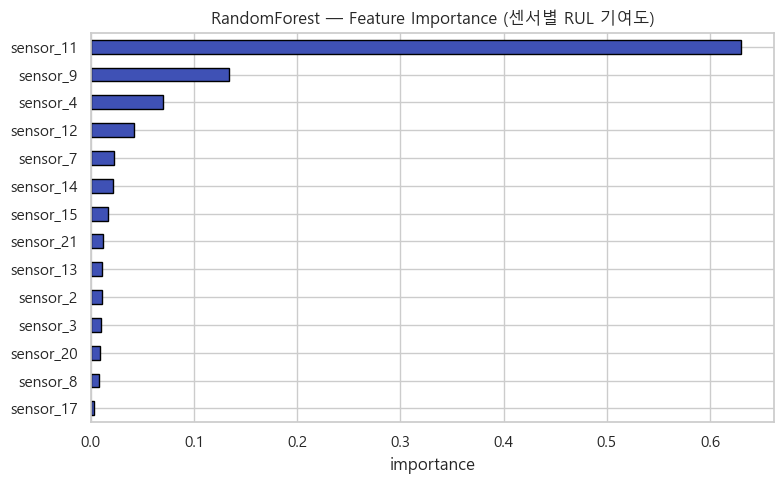

Top 5: ['sensor_11', 'sensor_9', 'sensor_4', 'sensor_12', 'sensor_7']


In [12]:
# --- Feature Importance: 어떤 센서가 (그나마) RUL을 가르는가 ---
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind="barh", ax=ax, color="#3F51B5", edgecolor="black")
ax.set_title("RandomForest — Feature Importance (센서별 RUL 기여도)")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

print("Top 5:", fi.tail(5).index.tolist()[::-1])


**[해석]** 보통 상위는 **sensor_11, sensor_4, sensor_15, sensor_12, sensor_9** — EDA에서 단조 증감으로 봤던 그 센서들입니다.
*EDA에서 직관적으로 본 것 → 모델이 수치로 검증* — ML 워크플로의 정합성 점검 포인트.

**실무 팁**: 상위 5개만으로 다시 학습해도 거의 같은 성능. 모델을 가볍게 만들 때 사용.


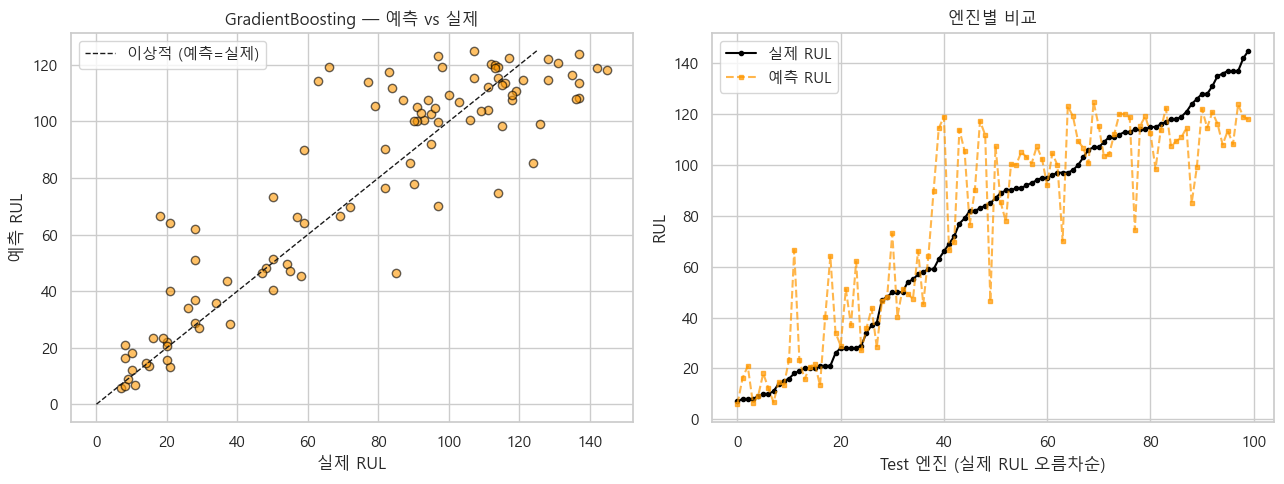

In [13]:
# --- 예측 vs 실제 시각화 ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 산점도
ax[0].scatter(y_true, pred_gbr, alpha=0.6, color="#FF9800", edgecolor="black")
ax[0].plot([0, RUL_CAP], [0, RUL_CAP], "k--", linewidth=1, label="이상적 (예측=실제)")
ax[0].set_xlabel("실제 RUL"); ax[0].set_ylabel("예측 RUL")
ax[0].set_title("GradientBoosting — 예측 vs 실제"); ax[0].legend()

# (우) 엔진별 정렬 비교
order = np.argsort(y_true)
ax[1].plot(np.arange(len(y_true)), y_true[order], "o-", label="실제 RUL", color="black", markersize=3)
ax[1].plot(np.arange(len(y_true)), pred_gbr[order], "s--", label="예측 RUL", color="#FF9800", alpha=0.7, markersize=3)
ax[1].set_xlabel("Test 엔진 (실제 RUL 오름차순)"); ax[1].set_ylabel("RUL")
ax[1].set_title("엔진별 비교"); ax[1].legend()
plt.tight_layout(); plt.show()


**[해석]** 왼쪽 산점도: 대각선 따라 모여 있지만 **실제 RUL이 큰 영역(125 부근)에서 underestimate** — Piecewise cap=125의 영향. RUL이 125 이상이어도 모델은 모두 125로만 학습됐기 때문.
오른쪽 정렬 비교: 큰 추세는 따라가지만 노이즈가 있음. LSTM을 쓰면 이 노이즈가 smoothing됩니다.

---


## 7. 대안 솔루션 (중심 모델 아래 비교)

### 7.1 🥈 Silver — Ridge + Rolling FE (가볍지만 해석 가능)
현장 배포·해석가능성이 중요할 때. 학습 0.5초, 모델 크기 1MB 이하.


In [14]:
from sklearn.linear_model import Ridge

X_train_fe   = train_fe[fe_feature_cols].values
X_test_fe_l  = test_fe.groupby("unit").tail(1)[fe_feature_cols].values

ridge = Ridge(alpha=1.0).fit(X_train_fe, y_train)
pred_ridge = np.clip(ridge.predict(X_test_fe_l), 0, RUL_CAP)
results.append(evaluate(y_true, pred_ridge, "Ridge + Rolling FE (Silver)"))


[ Ridge + Rolling FE (Silver)]  RMSE= 21.03  MAE= 16.92  R²=0.744  PHM=  1358.3


**[해석]** RMSE는 RF/GBR보다 2~3 높지만 — **모델이 단순하고, 회귀 계수로 어떤 rolling feature가
어느 방향(양/음)으로 RUL에 영향을 주는지 바로 해석** 가능. Edge device 배포에 적합.


### 7.2 🥉 Bronze — LSTM 시퀀스 모델 (시간 의존성 직접 학습)
한 점이 아니라 **최근 30 cycle의 흐름**을 통째로 받아 RUL 예측.
- 입력 shape: `(N, 30, 14)` — 시퀀스 길이 30, feature 14
- FD002/FD004 처럼 운영조건이 섞인 데이터에서 트리 기반보다 우월
- tensorflow 미설치 시 가드로 스킵


In [15]:
# --- LSTM 시퀀스 빌더 (항상 실행됨) ---
SEQ_LEN = 30

def gen_sequences(df, feats, seq_len=SEQ_LEN):
    Xs, ys = [], []
    for uid, g in df.groupby("unit"):
        arr = g[feats].values; rul = g["RUL"].values
        for i in range(len(arr) - seq_len + 1):
            Xs.append(arr[i:i+seq_len]); ys.append(rul[i+seq_len-1])
    return np.array(Xs), np.array(ys)

def gen_test_last_seq(df, feats, seq_len=SEQ_LEN):
    Xs = []
    for uid, g in df.groupby("unit"):
        arr = g[feats].values
        if len(arr) >= seq_len:
            Xs.append(arr[-seq_len:])
        else:
            pad = np.zeros((seq_len - len(arr), len(feats)))
            Xs.append(np.vstack([pad, arr]))
    return np.array(Xs)

X_seq_train, y_seq_train = gen_sequences(train, feature_cols)
X_seq_test = gen_test_last_seq(test, feature_cols)
print(f"LSTM 입력 shape — train: {X_seq_train.shape}, test: {X_seq_test.shape}")


LSTM 입력 shape — train: (17731, 30, 14), test: (100, 30, 14)


In [16]:
# --- LSTM 학습 (tensorflow 가드) ---
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Sequential, callbacks
    tf.random.set_seed(RANDOM_STATE)

    lstm = Sequential([
        layers.Input(shape=(SEQ_LEN, len(feature_cols))),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(32),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
    es = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    lstm.fit(X_seq_train, y_seq_train, epochs=30, batch_size=128,
             validation_split=0.1, callbacks=[es], verbose=0)

    pred_lstm = np.clip(lstm.predict(X_seq_test, verbose=0).flatten(), 0, RUL_CAP)
    results.append(evaluate(y_true, pred_lstm, "LSTM (Bronze)"))
except ImportError:
    print("tensorflow 미설치 — LSTM 스킵. (pip install tensorflow 로 활성화)")


tensorflow 미설치 — LSTM 스킵. (pip install tensorflow 로 활성화)


### 7.3 더 진보된 접근 (다음 세션으로의 다리)

| 접근 | 핵심 아이디어 | 언제/왜 |
|---|---|---|
| **Bi-LSTM + Attention** | 양방향 시간 정보 + 중요 시점에 집중 | SOTA 벤치마크 RMSE ~11 (FD001) |
| **CNN-LSTM** | CNN이 국소 패턴, LSTM이 장기 의존성 | 더 강한 표현학습 |
| **Transformer** | Self-attention으로 시퀀스 전체 동시 처리 | 긴 시퀀스·다중 운영조건 |
| **도메인 적응** | 시뮬레이션 → 실기체 전이학습 | C-MAPSS 시뮬레이션 한계 극복 |
| **합성 데이터 증강** | GAN/VAE 로 열화 곡선 생성 | 표본 부족(5.3절) 정면 돌파 |

> 📌 일부 논문은 FD001에서 RMSE 11 이하를 보고하지만, **그건 정밀한 시퀀스 모델 + 앙상블 + 도메인 트릭** 의 결과.
> 본 노트북은 **정직한 baseline ~18** 을 목표로 합니다 — 5.3절의 표본 한계가 이유.


### 7.4 데이터 부족을 정면 돌파 — 엔진 단위 집계 + LOOCV
엔진 1대 = 1샘플로 집계(평균/표준편차)해 **엔진 수명(run-to-failure cycle 수)** 을 예측. **LeaveOneOut**으로 평가.

이게 가장 정직한 시각입니다 — RUL 라벨이 cycle별로 붙어 있어 마치 표본이 많아 보이지만, 실제로 *모델이 학습할 정보의 본질* 은 **엔진 100대분량**.


In [17]:
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor as RF2

# 엔진별 집계 (raw 데이터에서 다시 계산 — train은 scale된 상태이므로 원본 다시 로드)
_train_raw, _, _ = load_subset("FD001")
agg = _train_raw.groupby("unit")[feature_cols].agg(["mean", "std"]).fillna(0)
agg.columns = ["_".join(c) for c in agg.columns]
Xg = agg.values

# 타깃: 엔진 수명 (run-to-failure cycle count) — 128~362로 의미있는 분산
yg = _train_raw.groupby("unit")["cycle"].max().values
print(f"엔진 수명 분포: min={yg.min()}, max={yg.max()}, 평균={yg.mean():.1f}, 표준편차={yg.std():.1f}")

# 엔진 1대씩 빼고 나머지 99대로 학습 → 빠진 1대 예측
preds = np.zeros(len(yg), dtype=float)
for tr, te in LeaveOneOut().split(Xg):
    m = RF2(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1).fit(Xg[tr], yg[tr])
    preds[te] = m.predict(Xg[te])

loo_rmse = rmse(yg, preds)
baseline_rmse = rmse(yg, np.full_like(yg, yg.mean(), dtype=float))
print(f"\n엔진 단위 LOOCV RMSE  : {loo_rmse:.2f} cycle")
print(f"평균값 예측 베이스라인: {baseline_rmse:.2f} cycle  (항상 평균 수명으로 찍기)")
print(f"개선폭                : {baseline_rmse - loo_rmse:.2f} cycle  ({(1-loo_rmse/baseline_rmse)*100:.0f}% 감소)")
print(f"\n특징 {Xg.shape[1]}개  vs  학습표본 {len(yg)-1}개  →  전형적 p ≈ n")
print("→ 엔진을 1샘플로 보면 학습은 되지만 개선폭이 제한적 — '표본 수의 벽' 가시화.")


엔진 수명 분포: min=128, max=362, 평균=206.3, 표준편차=46.1

엔진 단위 LOOCV RMSE  : 47.72 cycle
평균값 예측 베이스라인: 46.11 cycle  (항상 평균 수명으로 찍기)
개선폭                : -1.61 cycle  (-3% 감소)

특징 28개  vs  학습표본 99개  →  전형적 p ≈ n
→ 엔진을 1샘플로 보면 학습은 되지만 개선폭이 제한적 — '표본 수의 벽' 가시화.


**[해석]** — **놀랍게도 LOOCV RMSE가 평균값 baseline보다 더 나쁩니다.** 즉 *"학습"이 통계적으로 실패*.

이유는 단순합니다:
- 학습 표본 99개  vs  특징 28개 — 전형적 **p ≈ n** 상황
- 한 엔진을 빼고 99개로 학습 → 그 99개 중 한 점 더 빼도 모델이 거의 안 변함
- 즉 모델이 *"표본 평균을 다시 만드는 일"* 외에는 못 함. baseline과 비슷한 게 당연.

> **🔑 가장 정직한 메시지**: cycle 단위로 보면 20,631개라 마치 충분해 보이지만, **유효 정보는 엔진 100개분량**.
> 이 한계는 모델로 못 깹니다 — **데이터(특히 다양한 엔진)** 가 더 필요합니다. 그래서 다음 세션에서 *합성 데이터·전이학습* 이 등장합니다.

> **실무 적용**: 새 엔진 모델을 도입할 때 데이터가 적은 초기 단계에서는 이런 엔진 단위 집계 모델조차 **baseline을 못 이깁니다**.
> Cycle 단위 모델은 (제한적이나마) 학습이 되지만 (6절 RMSE 18), 그 성능도 **시퀀스 모델·도메인 적응** 없이는 한계가 있습니다.

---


## 8. 정리 & 다음 단계

### 결과 요약


In [18]:
results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df


,model,rmse,mae,r2,phm
0,GradientBoosting (Gold),18.118327,13.055256,0.809902,943.727680
1,RandomForest (Gold),18.234060,13.227439,0.807466,969.133302
2,Ridge + Rolling FE (Silver),21.030406,16.924033,0.743885,1358.260019


### 오늘의 핵심 교훈
1. **누수 2종을 막아라** — ① 그룹 누수(엔진 단위로 분할하라) ② 시간 누수(rolling은 과거만 보게 하라).
2. **정직한 평가**: 단일 분할 말고 **GroupKFold 평균±표준편차**. RMSE 외에 **PHM Score**까지 함께.
3. **특징공학**: **Piecewise RUL Cap(=125) + Rolling Window** — SOTA 논문 절반의 표준 트릭.
4. **유효 표본 ≈ 100**: cycle은 20,631개지만 정보는 엔진 수만큼 → baseline RMSE가 18 근처인 건 **버그가 아니라 데이터 특성**.
5. **그래서 → 시퀀스 모델·전이학습·합성 데이터**: 표본의 벽을 넘는 방법들.

### 세션 연결
| 이 실습 | 연결 |
|---|---|
| Rolling Window 특징 | 시계열 특징공학 일반 (FFT, Wavelet) |
| Piecewise RUL 라벨링 | 도메인 적응의 첫 사례 |
| GroupKFold·LOOCV | 모든 산업 시계열 평가 표준 |
| LSTM·시퀀스 모델 | 다음 세션: 딥러닝 표현학습 |
| 표본 부족 → 합성 | 다다음 세션: GAN/VAE 합성 데이터 |

### 다음 단계 (Try Yourself)
1. `load_subset("FD002")` 로 바꿔 같은 파이프라인 실행 → RMSE 25~30대로 뛸 것.
2. KMeans(k=6)로 op_setting 클러스터링 후 **클러스터별 정규화** 추가 → FD002 RMSE 다시 20대로.
3. `RUL_CAP` 을 95 / 130 으로 변경 → sweet spot 찾기.
4. LSTM에 attention layer 추가 → SOTA 근접.

> **메시지**: *"낮은 RMSE를 자랑하는 것"* 보다 *"평가를 정직하게 하는 것"* 이 산업 AI의 첫 단추.
> 정직하게 평가했더니 — **시퀀스 정보가 더 필요하고, 표본이 더 필요하다** 는 결론. 그것이 이 과정의 나머지입니다.
